In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)
num_rows = 1000

# Sample data pools
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Kolkata', 'Chennai', 'mumbai', 'DELHI', 'bangalore'] # Mixed casing for cleaning practice
payment_modes = ['Credit Card', 'UPI', 'Cash on Delivery', 'Net Banking']
delivery_statuses = ['Delivered', 'Shipped', 'Pending', 'Cancelled']

categories_products = {
    'Electronics': ['Laptop', 'Smartphone', 'Wireless Headphones', 'Smartwatch'],
    'Clothing': ['T-Shirt', 'Jeans', 'Jackets', 'Sneakers'],
    'Home Decor': ['Wall Clock', 'Sofa Cover', 'Table Lamp', 'Curtains']
}

data = []
start_date = datetime(2026, 1, 1)

# Generate 1000 base rows
for i in range(num_rows):
    cat = random.choice(list(categories_products.keys()))
    prod = random.choice(categories_products[cat])

    qty = random.randint(1, 5)
    u_price = random.randint(15, 1200)

    # Intentionally inject bad data (Negative validation errors)
    if i in [10, 100, 250]:
        qty = -2
    if i in [20, 150, 300]:
        u_price = -150

    o_date = start_date + timedelta(days=random.randint(0, 90))

    data.append({
        'Order ID': f"ORD{10000 + i}",
        'Customer ID': f"CUST{random.randint(100, 350)}", # Overlapping IDs to show repeat customers
        'Product Name': prod,
        'Category': cat,
        'Quantity': qty,
        'Unit Price': u_price,
        'Total Amount': qty * u_price,
        'Order Date': o_date.strftime('%Y-%m-%d'),
        'Payment Mode': random.choice(payment_modes),
        'Delivery Status': random.choice(delivery_statuses),
        'City or Region': random.choice(cities)
    })

df_raw = pd.DataFrame(data)

# Intentionally inject Missing Values (NaNs) into ~4-5% of the data
df_raw.loc[df_raw.sample(frac=0.05, random_state=1).index, 'Quantity'] = np.nan
df_raw.loc[df_raw.sample(frac=0.04, random_state=2).index, 'Category'] = np.nan
df_raw.loc[df_raw.sample(frac=0.03, random_state=3).index, 'Payment Mode'] = np.nan

# Intentionally append 30 Duplicate rows
duplicates = df_raw.sample(n=30, random_state=42)
df_raw = pd.concat([df_raw, duplicates], ignore_index=True)

# Export to raw CSV
df_raw.to_csv('ecommerce_data.csv', index=False)
print(f"Success! Generated 'ecommerce_data.csv' with {len(df_raw)} rows including raw errors.")

Success! Generated 'ecommerce_data.csv' with 1030 rows including raw errors.


In [ ]:
print(f"Shape of DataFrame before removing duplicates: {df_raw.shape}")

df_cleaned = df_raw.drop_duplicates().copy()

print(f"Shape of DataFrame after removing duplicates: {df_cleaned.shape}")

Shape of DataFrame before removing duplicates: (1030, 11)
Shape of DataFrame after removing duplicates: (1000, 11)


In [ ]:
import pandas as pd
import numpy as np

# 1. Load the raw dataset
df = pd.read_csv('ecommerce_data.csv')
print(f"Initial shape with errors: {df.shape}")

# 2. Check initial issues
print("\n--- Missing values before cleaning ---")
print(df.isnull().sum())
print(f"\nDuplicate rows count: {df.duplicated().sum()}")

# 3. Handle Missing Values
# Fill missing numeric values with the median
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

# Fill missing categorical values with a fallback label
df['Category'] = df['Category'].fillna('Unknown')
df['Payment Mode'] = df['Payment Mode'].fillna('Unknown')

# 4. Remove Duplicate Records
df = df.drop_duplicates()
print(f"\nShape after dropping duplicates: {df.shape}")

# 5. Data Validation (Fixing Negative Values & Typos)
# Convert negative quantities or prices to absolute positive values
df['Quantity'] = df['Quantity'].abs()
df['Unit Price'] = df['Unit Price'].abs()

# Standardize City Names (Fixing mixed casing like 'mumbai' vs 'Mumbai')
df['City or Region'] = df['City or Region'].str.capitalize()

# Recalculate Total Amount accurately based on cleaned metrics
df['Total Amount'] = df['Quantity'] * df['Unit Price']

# Convert Order Date to standard DateTime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 6. Save Cleaned Dataset
df.to_csv('Cleaned_Ecommerce_Data.csv', index=False)
print("\nSuccess! Cleaned dataset saved as 'Cleaned_Ecommerce_Data.csv'")
print(f"Final clean shape: {df.shape}")


Initial shape with errors: (1030, 11)

--- Missing values before cleaning ---
Order ID            0
Customer ID         0
Product Name        0
Category           42
Quantity           51
Unit Price          0
Total Amount        0
Order Date          0
Payment Mode       30
Delivery Status     0
City or Region      0
dtype: int64

Duplicate rows count: 30

Shape after dropping duplicates: (1000, 11)

Success! Cleaned dataset saved as 'Cleaned_Ecommerce_Data.csv'
Final clean shape: (1000, 11)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Load the cleaned dataset
df = pd.read_csv('Cleaned_Ecommerce_Data.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

print("==================================================")
print("             TASK 2: SALES KPI SUMMARY            ")
print("==================================================")

# Compute Core KPIs
total_revenue = df['Total Amount'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_revenue / total_orders
total_units_sold = df['Quantity'].sum()
top_category = df.groupby('Category')['Total Amount'].sum().idxmax()
top_product = df.groupby('Product Name')['Total Amount'].sum().idxmax()

# Display KPI Table
kpi_summary = pd.DataFrame({
    'KPI Metric': ['Total Revenue', 'Total Orders', 'Average Order Value (AOV)', 'Total Units Sold', 'Top Category', 'Best Selling Product'],
    'Value': [f"${total_revenue:,.2f}", f"{total_orders:,}", f"${avg_order_value:,.2f}", f"{int(total_units_sold):,}", top_category, top_product]
})
print(kpi_summary.to_string(index=False))

print("\n==================================================")
print("         TASK 3: GENERATING VISUALIZATIONS        ")
print("==================================================")

# Chart 1: Bar Chart (Revenue by Category)
plt.figure(figsize=(9, 5))
cat_revenue = df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_revenue, x='Total Amount', y='Category', palette='Blues_r')
plt.title('Total Revenue Contribution by Product Category', fontsize=14, pad=15)
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('revenue_by_category.png', dpi=300)
plt.close()
print("[Saved] 'revenue_by_category.png' generated successfully.")

# Chart 2: Line Chart (Monthly Sales Performance Trend)
# Creating Year-Month feature for chronological trend line
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Year-Month')['Total Amount'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_trend, x='Year-Month', y='Total Amount', marker='o', linewidth=2.5, color='#2ecc71')
plt.title('Monthly Sales Performance Timeline', fontsize=14, pad=15)
plt.xlabel('Month Period', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=300)
plt.close()
print("[Saved] 'monthly_sales_trend.png' generated successfully.")

# Chart 3: Pie Chart (Sales Share by Payment Mode)
plt.figure(figsize=(7, 7))
payment_dist = df.groupby('Payment Mode')['Total Amount'].sum()
plt.pie(payment_dist, labels=payment_dist.index, autopct='%1.1f%%', startangle=140,
        colors=['#3498db', '#f1c40f', '#e74c3c', '#9b59b6', '#95a5a6'])
plt.title('Sales Breakdown by Payment Infrastructure', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('payment_mode_share.png', dpi=300)
plt.close()
print("[Saved] 'payment_mode_share.png' generated successfully.")
print("\nAll assets compiled successfully. Check your workspace directory for the image exports!")


             TASK 2: SALES KPI SUMMARY            
               KPI Metric         Value
            Total Revenue $1,894,269.00
             Total Orders         1,000
Average Order Value (AOV)     $1,894.27
         Total Units Sold         3,058
             Top Category      Clothing
     Best Selling Product      Sneakers

         TASK 3: GENERATING VISUALIZATIONS        


/tmp/ipykernel_790/3271940024.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='Total Amount', y='Category', palette='Blues_r')


[Saved] 'revenue_by_category.png' generated successfully.
[Saved] 'monthly_sales_trend.png' generated successfully.
[Saved] 'payment_mode_share.png' generated successfully.

All assets compiled successfully. Check your workspace directory for the image exports!


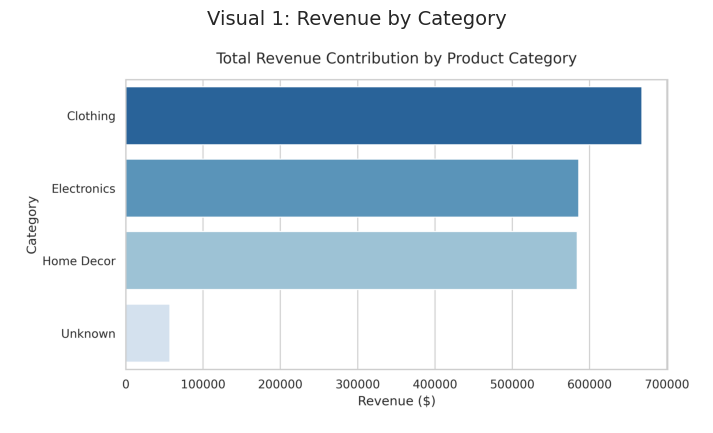

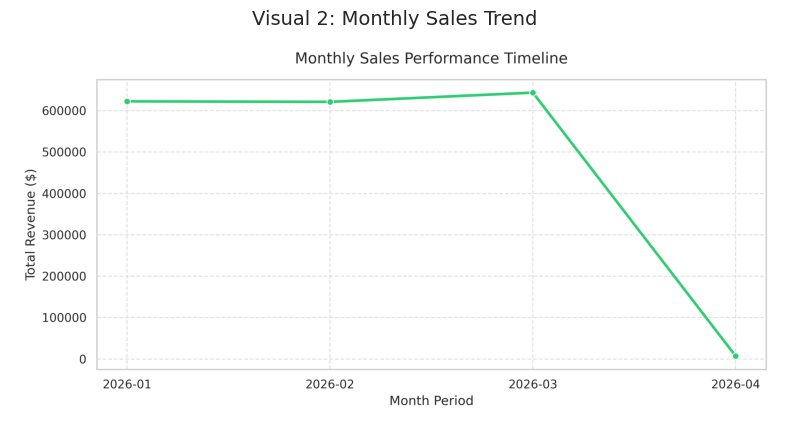

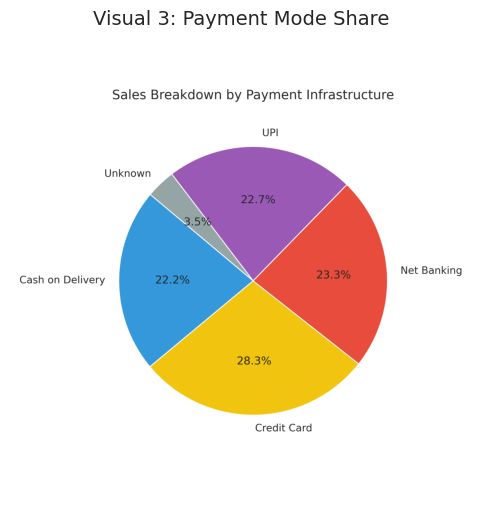

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 1. Display Revenue by Category Chart
try:
    img1 = mpimg.imread('revenue_by_category.png')
    plt.figure(figsize=(9, 5))
    plt.imshow(img1)
    plt.axis('off')
    plt.title("Visual 1: Revenue by Category", fontsize=14, pad=10)
    plt.show()
except FileNotFoundError:
    print("Error: 'revenue_by_category.png' not found in workspace.")

# 2. Display Monthly Sales Trend Chart
try:
    img2 = mpimg.imread('monthly_sales_trend.png')
    plt.figure(figsize=(10, 5))
    plt.imshow(img2)
    plt.axis('off')
    plt.title("Visual 2: Monthly Sales Trend", fontsize=14, pad=10)
    plt.show()
except FileNotFoundError:
    print("Error: 'monthly_sales_trend.png' not found in workspace.")

# 3. Display Payment Mode Share Chart
try:
    img3 = mpimg.imread('payment_mode_share.png')
    plt.figure(figsize=(6, 6))
    plt.imshow(img3)
    plt.axis('off')
    plt.title("Visual 3: Payment Mode Share", fontsize=14, pad=10)
    plt.show()
except FileNotFoundError:
    print("Error: 'payment_mode_share.png' not found in workspace.")
